# DATA 266 Lab 1, Task 1: character-level GPT from scratch

Training was run with `python src/gpt_char.py --config src/config.yaml --out_dir .` (raw log in `logs/`). This notebook loads the trained checkpoint and walks through each part of the task with outputs: preprocessing, the model and its causal mask, training curves, metrics, and live text generation.

In [1]:
import os, sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "src":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import gpt_char

def read_text(path):
    # files written on Windows may use the cp1252 code page instead of UTF-8
    raw = open(path, "rb").read()
    for enc in ("utf-8", "cp1252"):
        try:
            return raw.decode(enc)
        except UnicodeDecodeError:
            pass
    return raw.decode("utf-8", errors="replace")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("member folder:", ROOT.name)
print("torch", torch.__version__, "| device:", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

member folder: akhilesh
torch 2.11.0+cu128 | device: NVIDIA GeForce RTX 5090


## 1.1 Data preprocessing

Character-level vocabulary built from the 100K training stories (characters seen at least 50 times), with my own `char_to_idx` and `idx_to_char` mappings. Text is cut into fixed-length 256-character windows where the target is the input shifted by one character.

In [2]:
vocab = json.loads(read_text("data_processed/vocab.json"))
idx_to_char = vocab["itos"]
char_to_idx = vocab["char_to_idx"]
print("vocabulary size:", len(idx_to_char))
print("characters:", "".join(c for c in idx_to_char[2:]))
print("special tokens: index 0 = end of story, index 1 = unknown")

tok = gpt_char.CharTokenizer(idx_to_char)
text = "Once upon a time, Lily found a red ball."
ids = tok.encode(text)
print("\nencoded:", ids.tolist())
print("decoded:", tok.decode(ids.tolist()))

# one input/target pair, as used in training (block size 256; showing the first 40 positions)
seq = tok.encode("Once upon a time there was a little dog named Max. " * 6)[:257].astype(np.int64)
x, y = seq[:-1], seq[1:]
print("\ninput :", repr(tok.decode(x[:40].tolist())))
print("target:", repr(tok.decode(y[:40].tolist())))

vocabulary size: 79
characters: 
 !"',-.012345:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz¦âœ˜“”€™
special tokens: index 0 = end of story, index 1 = unknown

encoded: [33, 58, 47, 49, 3, 65, 60, 59, 58, 3, 45, 3, 64, 53, 57, 49, 7, 3, 30, 53, 56, 69, 3, 50, 59, 65, 58, 48, 3, 45, 3, 62, 49, 48, 3, 46, 45, 56, 56, 9]
decoded: Once upon a time, Lily found a red ball.

input : 'Once upon a time there was a little dog '
target: 'nce upon a time there was a little dog n'


## 1.2 Model

Six pre-LayerNorm Transformer blocks, each with hand-written multi-head self-attention (causal mask), LayerNorm, a GELU feed-forward network and residual connections, plus learned token and positional embeddings and a language-modelling head.

In [3]:
ck = torch.load("checkpoints/best.pt", map_location=device)
model = gpt_char.build_model(ck["args"], len(ck["itos"])).to(device)
model.load_state_dict(ck["model"])
model.eval()
tok = gpt_char.CharTokenizer(ck["itos"])  # same mapping the model was trained with
print(model)
print("\nparameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("checkpoint epoch:", ck["epoch"], "| validation loss:", round(ck["val_loss"], 4))

GPT(
  (tok_emb): Embedding(79, 384)
  (pos_emb): Embedding(256, 384)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (ln1): LayerNorm()
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm()
      (ffn): FeedForward(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm()
  (lm_head): Linear(in_features=384, out_features=79, bias=False)
)

parameters: 10,776,192
checkpoint epoch: 10 | validation loss: 0.5568


### Checking the causal mask

The top-left corner of the attention mask shows each position can only see itself and earlier positions. The second test changes every token from position 40 onward and confirms that the predictions for positions 0-39 do not change at all, so no information leaks from the future.

In [4]:
print(model.blocks[0].attn.mask[0, 0, :8, :8].int())

x = torch.randint(0, tok.vocab_size, (1, 64), device=device)
x2 = x.clone()
x2[0, 40:] = (x2[0, 40:] + 1) % tok.vocab_size
with torch.no_grad():
    a, b = model(x).float(), model(x2).float()
print("max change in logits at positions 0-39 :", (a[0, :40] - b[0, :40]).abs().max().item())
print("max change in logits at positions 40-63:", (a[0, 40:] - b[0, 40:]).abs().max().item())

tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0', dtype=torch.int32)


max change in logits at positions 0-39 : 0.0
max change in logits at positions 40-63: 20.770179748535156


## 1.3 Training: loss curves and per-epoch history

Cross-entropy loss, 1,000-step linear warmup then cosine decay, 10 epochs.

In [5]:
hist = pd.DataFrame(json.load(open("outputs/history.json")))
hist.round(4)

,epoch,train_loss_running,train_loss_eval,train_acc,val_loss,val_acc,val_ppl,val_bpc,epoch_time_s,train_tok_per_s
0,1,1.0089,0.7000,0.7780,0.7031,0.7774,2.0200,1.0143,172.2559,520113.3339
1,2,0.7066,0.6488,0.7935,0.6545,0.7923,1.9242,0.9443,168.3787,532089.6425
2,3,0.6688,0.6218,0.8016,0.6288,0.8000,1.8753,0.9072,167.3238,535444.1960
3,4,0.6459,0.6025,0.8072,0.6113,0.8050,1.8429,0.8819,167.3391,535395.4960
4,5,0.6282,0.5878,0.8117,0.5983,0.8091,1.8190,0.8632,168.2667,532444.0171
5,6,0.6131,0.5733,0.8160,0.5860,0.8129,1.7968,0.8455,191.4282,468021.8578
6,7,0.5993,0.5607,0.8198,0.5752,0.8162,1.7775,0.8298,250.3474,357872.9509
7,8,0.5871,0.5498,0.8231,0.5661,0.8190,1.7614,0.8167,249.2271,359481.6155
8,9,0.5773,0.5418,0.8255,0.5598,0.8208,1.7504,0.8077,250.1639,358135.4805
9,10,0.5708,0.5373,0.8269,0.5568,0.8217,1.7450,0.8032,249.2733,359415.1112


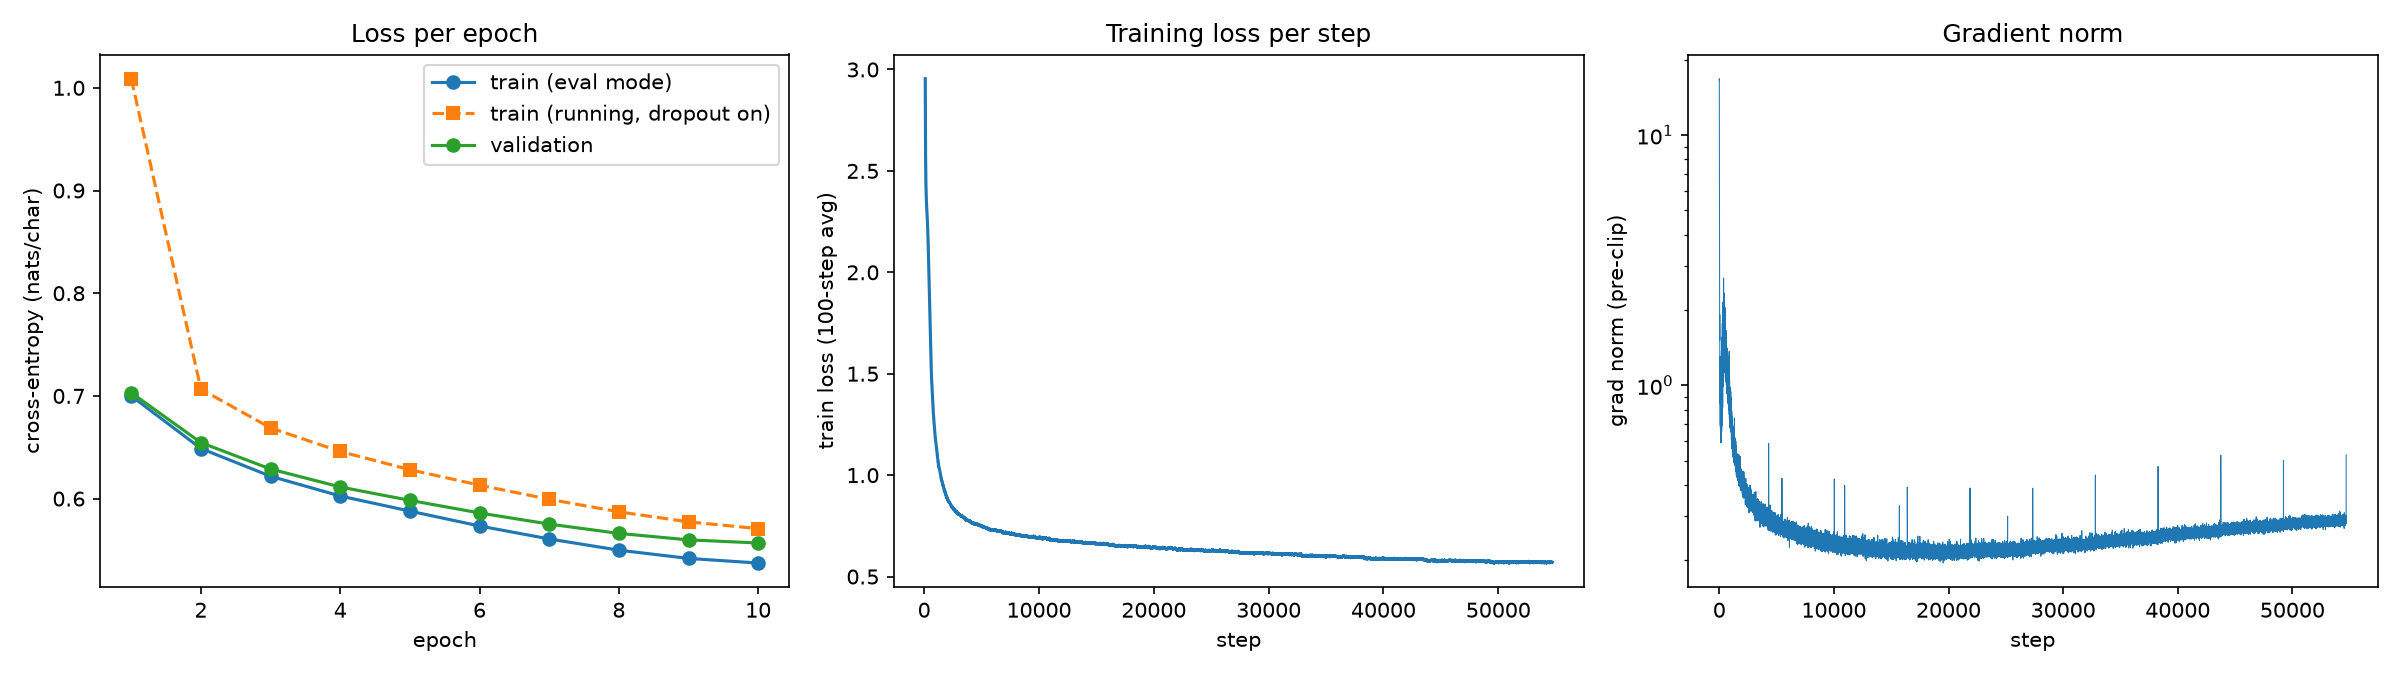

In [6]:
from IPython.display import Image, display
display(Image("outputs/loss_curves.png"))

## Evaluation metrics

In [7]:
pd.set_option("display.max_rows", 50)
pd.read_csv("metrics_report.csv")

,metric,value
0,train_cross_entropy_loss,0.537266
1,train_cross_entropy_loss_running_last_epoch,0.570817
2,validation_cross_entropy_loss,0.556769
3,train_perplexity,1.71132
4,validation_perplexity,1.74503
5,validation_bits_per_character,0.803248
6,generalization_gap_val_minus_train,0.0195035
7,top1_next_char_accuracy_val,0.821743
8,top1_next_char_accuracy_train,0.826884
9,distinct_1_word,0.343701


## Text generation

Live samples from the trained model: temperature 0.8 sampling and greedy decoding.

In [8]:
torch.manual_seed(266)

def sample(prompt, n=400, temperature=0.8, greedy=False):
    idx = torch.from_numpy(tok.encode(prompt).astype(np.int64))[None].to(device)
    out = gpt_char.generate(model, idx, n, temperature=temperature, greedy=greedy)
    return tok.decode(out[0].tolist()).replace(gpt_char.EOS, "\n<EOS>\n")

for p in ["Once upon a time", "The little cat wanted to"]:
    print(f"--- {p!r}, temperature 0.8 ---")
    print(sample(p), "\n")
print("--- 'Once upon a time', greedy ---")
print(sample("Once upon a time", greedy=True))

--- 'Once upon a time', temperature 0.8 ---


Once upon a time there was a little girl who was very sad. Every day she would cry and always try to make her mama happy. One day she was feeling sad and wanted to go to the store. She asked her mom if she could go to the store to buy some new pictures. Her mom said she could pick one of the pictures for her to bring some crayons. Her mom said yes, but she had to let her go.

As they were walking to the store, Li 

--- 'The little cat wanted to', temperature 0.8 ---


The little cat wanted to try and be friends.

The little cat went for a walk and looked for a safe spot. As she walked, she saw a seagull. The seagull was so happy that the little cat explained that he didn't need to leave his home alone. The little cat was sad because he didn't want to leave the seagull alone. 

The little cat thought about how delicate it was to leave the seagull alone near the plant. So, the little ca 

--- 'Once upon a time', greedy ---


Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big bush with lots of bright yellow berries. She wanted to eat them, but she was scared of the bush.

Lily went to her mom and said, "Mommy, can I have these berries?" Her mom said, "Yes, you can have them." Lily was so happy and thanked her mom. She took a big bite and said, "Mmm, these berries are


### Saved samples used for the metrics and failure analysis

In [9]:
print(read_text("outputs/samples.txt")[:3000])






































There was a big red ball. It was blue and had long hair and a swing. It 


## 1.4 Failure analysis

The three failure cases (loss of coherence, hallucination/contradiction, and repetition under greedy decoding) are written up in `failure_analysis.md`, using snippets from `outputs/samples.txt` above.